<a href="https://colab.research.google.com/github/Saireshma22/Syntecxhub_House_Price_Prediction/blob/main/Syntecxhub_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [21]:
df = pd.read_csv("house_prices.csv")
df.head()

,area,bedrooms,bathrooms,stories,parking,price
0,2600,3,2,2,1,550000
1,3000,4,3,2,2,565000
2,3200,3,2,1,2,610000
3,3600,4,3,2,2,680000
4,4000,5,4,2,3,725000


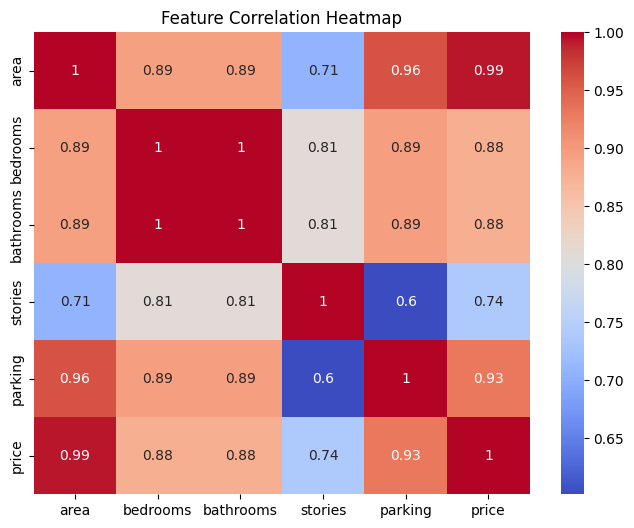

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [23]:
X = df.drop("price", axis=1)
y = df["price"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(6, 5) (2, 5)


In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 28491.155150712966
R² Score: 0.9051283071647044


In [28]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,area,119.736842
1,bedrooms,-9254.385965
2,bathrooms,-9254.385965
3,stories,36228.070175
4,parking,25482.456140


In [29]:
joblib.dump(model, "house_price_model.pkl")
print("Model saved successfully")

Model saved successfully


In [31]:
example_house = pd.DataFrame(
    [[3500, 4, 3, 2, 2]],
    columns=["area", "bedrooms", "bathrooms", "stories", "parking"]
)

predicted_price = loaded_model.predict(example_house)
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 663640.3508771919


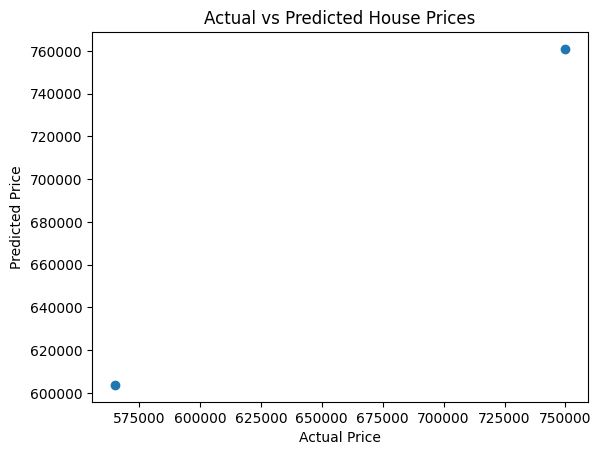

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()